Лабораторная 5


пакеты h5py для чтения digitStruct.mat и torchmetrics для map

In [1]:
import subprocess
import sys

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "h5py", "torchmetrics"]
)


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


0

настройка путей и устройства


In [2]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.transforms.functional as F
from torch.utils.data import DataLoader



ROOT = Path.cwd()
for cand in (ROOT, ROOT / "lab_5", ROOT.parent / "lab_5"):
    if cand.is_dir() and (cand / "svhn_bbox.py").is_file():
        ROOT = cand.resolve()
        break


TEST1 = ROOT / "test 1"
TEST2 = ROOT / "test 2"
TEST_MAT = TEST2 / "digitStruct.mat"
sys.path.insert(0, str(ROOT))
from svhn_train_data import ensure_svhn_train
TRAIN_DIR = ensure_svhn_train(ROOT)
TRAIN_MAT = TRAIN_DIR / "digitStruct.mat"
if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.backends.cudnn.benchmark = True





print("ROOT", ROOT)
print("SVHN train", TRAIN_DIR)
print("SVHN test (оценка задания)", TEST2)
print("Свои фото", TEST1)
print("device", device, end="")
if device.type == "cuda":
    print(" —", torch.cuda.get_device_name(0))
else:
    print()

ROOT C:\Users\basev\PycharmProjects\ML_Labs\lab_5
SVHN train C:\Users\basev\PycharmProjects\ML_Labs\lab_5\train
SVHN test (оценка задания) C:\Users\basev\PycharmProjects\ML_Labs\lab_5\test 2
Свои фото C:\Users\basev\PycharmProjects\ML_Labs\lab_5\test 1
device cuda — NVIDIA GeForce RTX 5070


Датасет и модель

Используется Faster R-CNN с лёгким backbone MobileNetV3-Large и FPN.   Классов 11 фон и десять цифр SVHN


In [3]:
import os

from svhn_bbox import SVHNDetectionDataset, collate_fn, get_model
MAX_TRAIN_IMAGES = 10000
BATCH = 16
NUM_WORKERS = 0


def to_tensor_eval(img, target):
    return F.to_tensor(img), target




class TDataset(SVHNDetectionDataset):
    def __getitem__(self, idx):
        img, target = super().__getitem__(idx)
        return to_tensor_eval(img, target)
    def __getstate__(self):
        return SVHNDetectionDataset.__getstate__(self)
    def __setstate__(self, state):
        SVHNDetectionDataset.__setstate__(self, state)


train_ds = TDataset(TRAIN_DIR, TRAIN_MAT, max_images=MAX_TRAIN_IMAGES)
loader_kw = dict(
    batch_size=BATCH,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=(device.type == "cuda"),
)
if NUM_WORKERS > 0:
    loader_kw["persistent_workers"] = True
train_loader = DataLoader(train_ds, **loader_kw)




model = get_model(num_classes=11, backbone="mobilenet_v3").to(device)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=1e-4)
lr_sched = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
print("train размер", len(train_ds), "| num_workers", NUM_WORKERS, "| mobilenet_v3")

train размер 10000 | num_workers 0 | mobilenet_v3


Обучение

Оптимизатор SGD по обучающей выборке SVHN.

In [4]:
EPOCHS = 6


def train_one_epoch():
    model.train()
    losses_acc = []
    for images, targets in train_loader:
        images = [im.to(device) for im in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        losses = sum(loss_dict.values())
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        losses_acc.append(losses.item())
    return float(np.mean(losses_acc))





for ep in range(1, EPOCHS + 1):
    m = train_one_epoch()
    lr_sched.step()
    print(f"epoch {ep}/{EPOCHS} mean loss {m:.4f}")
ckpt = ROOT / "frcnn_svhn.pt"
torch.save(model.state_dict(), ckpt)
print("веса сохранены", ckpt)
train_ds.close()

epoch 1/6 mean loss 1.1594
epoch 2/6 mean loss 1.0667
epoch 3/6 mean loss 1.0586
epoch 4/6 mean loss 1.0599
epoch 5/6 mean loss 1.0399
epoch 6/6 mean loss 1.0314
веса сохранены C:\Users\basev\PycharmProjects\ML_Labs\lab_5\frcnn_svhn.pt


Метрики на тестовой части SVHN

Считаются mAP , в том числе map при IoU 0.5 , precision и recall при IoU не ниже 0.5 и пороге уверенности 0.5 , средний IoU по истинно положительным сопоставлениям



In [6]:
import sys
from pathlib import Path
for cand in (Path.cwd(), Path.cwd() / "lab_5", Path.cwd().parent / "lab_5"):
    if (cand / "lab5_runtime.py").is_file():
        sys.path.insert(0, str(cand.resolve()))
        break
from lab5_runtime import lab5_paths_and_device
ROOT, device, _TEST1, TEST2, TEST_MAT = lab5_paths_and_device()
import torch
from svhn_bbox import SVHNDetectionDataset, get_model
from svhn_eval import evaluate_svhn_test
BACKBONE = "mobilenet_v3"
MAX_TEST_IMAGES = 10000
model = get_model(num_classes=11, backbone=BACKBONE).to(device)
model.load_state_dict(torch.load(ROOT / "frcnn_svhn.pt", map_location=device))
test_ds = SVHNDetectionDataset(TEST2, TEST_MAT, max_images=MAX_TEST_IMAGES)
try:
    metrics = evaluate_svhn_test(model, test_ds, device, score_thresh=0.5, iou_thresh_pr=0.5)
finally:
    test_ds.close()



print("Результаты на SVHN test")
for k in sorted(metrics.keys()):
    v = metrics[k]
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

map50 = metrics.get("map_50", metrics.get("map", 0))
print()



--- Результаты на SVHN test ---
fn: 5017.0000
fp: 2481.0000
map: 0.3252
map_50: 0.7169
map_75: 0.2356
mar_10: 0.4088
mar_100: 0.4088
mean_iou_matched_tp: 0.7420
precision_iou50: 0.8571
recall_iou50: 0.7478
tp: 14876.0000

mAP @0.5IoU: 0.7168853878974915
Требование mAP >= 0.6: выполнено


Свои фото


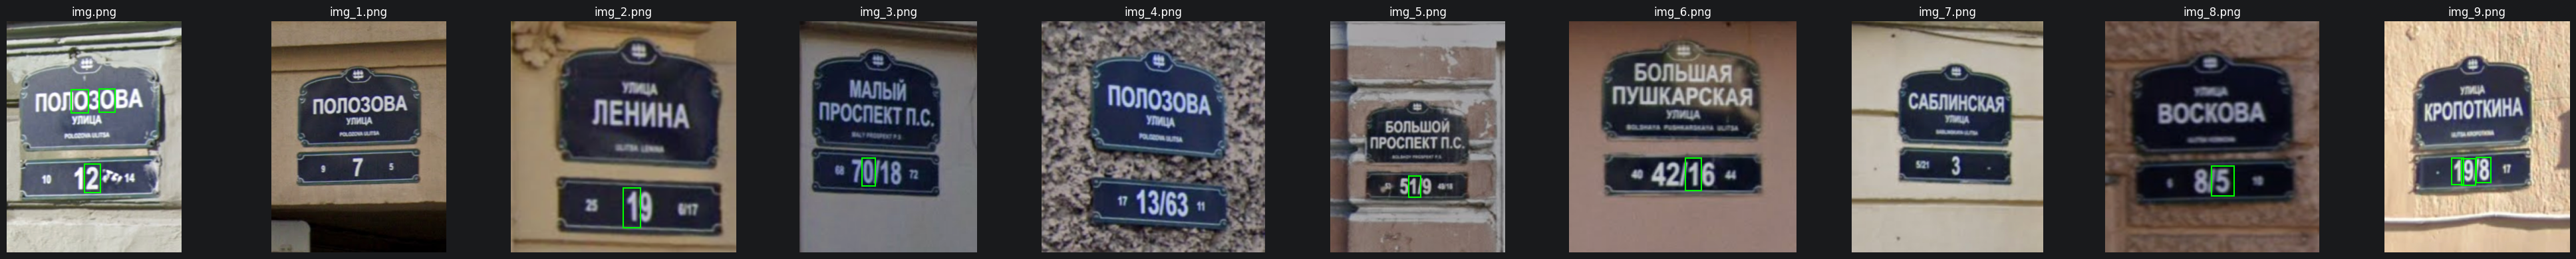

In [5]:
import sys
from pathlib import Path
for cand in (Path.cwd(), Path.cwd() / "lab_5", Path.cwd().parent / "lab_5"):
    if (cand / "lab5_runtime.py").is_file():
        sys.path.insert(0, str(cand.resolve()))
        break
from lab5_runtime import lab5_paths_and_device
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.transforms.functional as F

ROOT, device, TEST1, _TEST2, _TEST_MAT = lab5_paths_and_device()
from svhn_bbox import get_model
BACKBONE = "mobilenet_v3"
model = get_model(num_classes=11, backbone=BACKBONE).to(device)
model.load_state_dict(torch.load(ROOT / "frcnn_svhn.pt", map_location=device))
model.eval()

paths = sorted(list(TEST1.glob("*.png")) + list(TEST1.glob("*.jpg")))
if not paths:
    print("Нет изображений в test 1 — добавьте свои фото.")
else:
    n = min(10, len(paths))
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, p in zip(axes, paths[:n]):
        im = F.to_tensor(Image.open(p).convert("RGB")).to(device)
        with torch.no_grad():
            out = model([im])[0]
        img_np = im.cpu().permute(1, 2, 0).numpy()
        ax.imshow(np.clip(img_np, 0, 1))
        for b, s, lab in zip(out["boxes"], out["scores"], out["labels"]):
            if s < 0.5:
                continue
            x1, y1, x2, y2 = b.cpu().numpy()
            ax.add_patch(
                plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", linewidth=1.5)
            )
        ax.set_title(p.name)
        ax.axis("off")
    plt.tight_layout()
    plt.show()